# Live Plotting

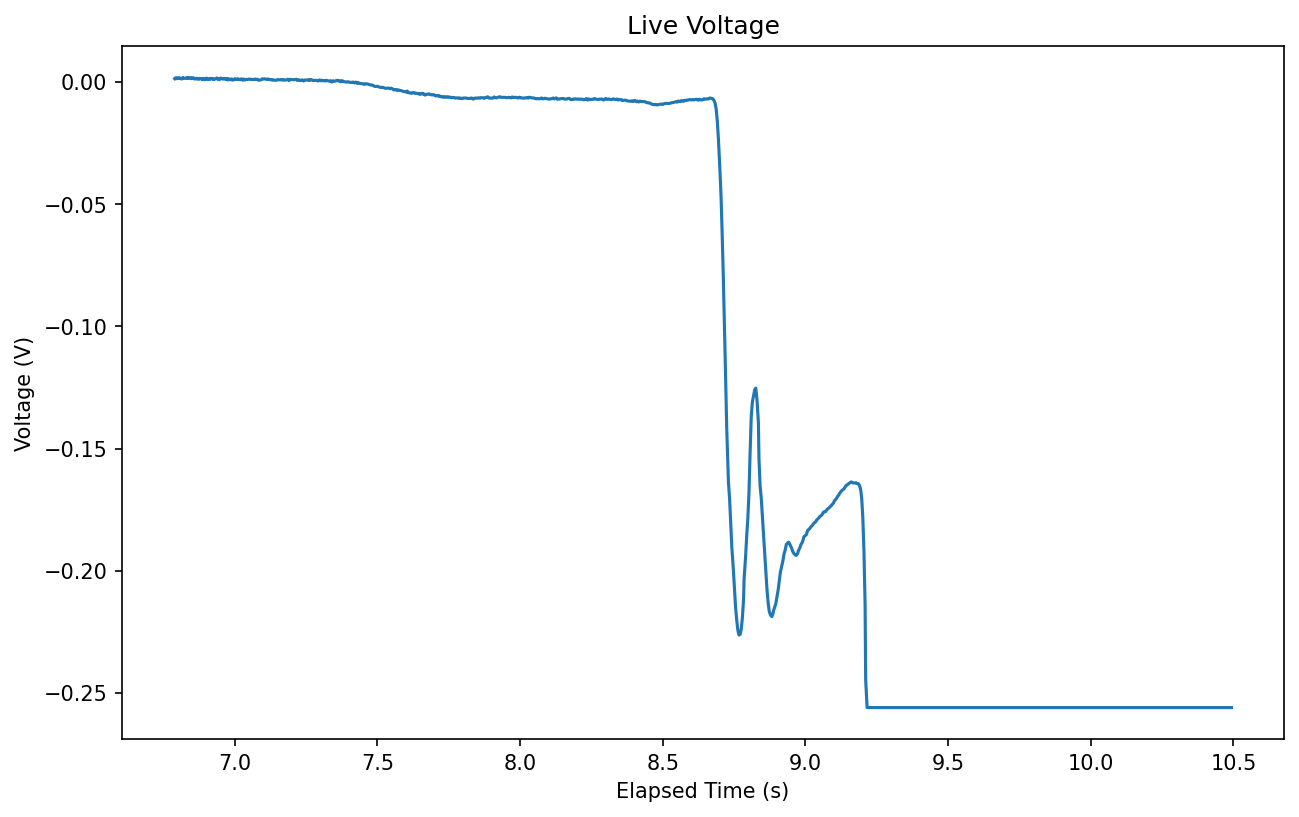

In [82]:
import matplotlib.pyplot as plt
import serial
from IPython.display import clear_output
import numpy as np
import struct

plt.rcParams["figure.dpi"] = 150
plt.rcParams["figure.figsize"] = (10, 6)

times = []
voltages = []

start_time = 0

data_format = "<fL"
struct_size = struct.calcsize(data_format)

counter = 0

points_to_plot = 1000

with serial.Serial("/dev/cu.usbmodem14201", 115200) as ser:

    while True:

        incoming_byte = ser.read(1)

        if incoming_byte == b"\xAA":

            payload = ser.read(struct_size)
        
            voltage, time = struct.unpack(data_format, payload)

            times.append(time / 1000)
            voltages.append(voltage)
        
        clear_output(wait = True)
            
        try:

            if len(times) > points_to_plot:
                times = times[-points_to_plot:-1]
                voltages = voltages[-points_to_plot:-1]

            if counter % 30 == 0:

                plt.plot(np.array(times) - start_time, voltages)
                plt.title("Live Voltage")
                plt.xlabel("Elapsed Time (s)")
                plt.ylabel("Voltage (V)")
                plt.show()

            counter += 1

        except KeyboardInterrupt:
            break





# Data Recording

In [83]:
import pandas as pd
import time

data_frame = pd.DataFrame(columns = ["Times", "Voltages"])

start_time = 0

data_format = "<fL"
struct_size = struct.calcsize(data_format)

counter = 0

time_to_record = 120

end_time = time.time() + time_to_record

with serial.Serial("/dev/cu.usbmodem14201", 115200) as ser:

    while time.time() < end_time:

        incoming_byte = ser.read(1)

        if incoming_byte == b"\xAA":

            payload = ser.read(struct_size)
        
            voltage, timepoint = struct.unpack(data_format, payload)

            data_frame.loc[len(data_frame)] = [timepoint, voltage]
            






505.225


Text(0.5, 1.0, 'Frequency: 505 Hz')

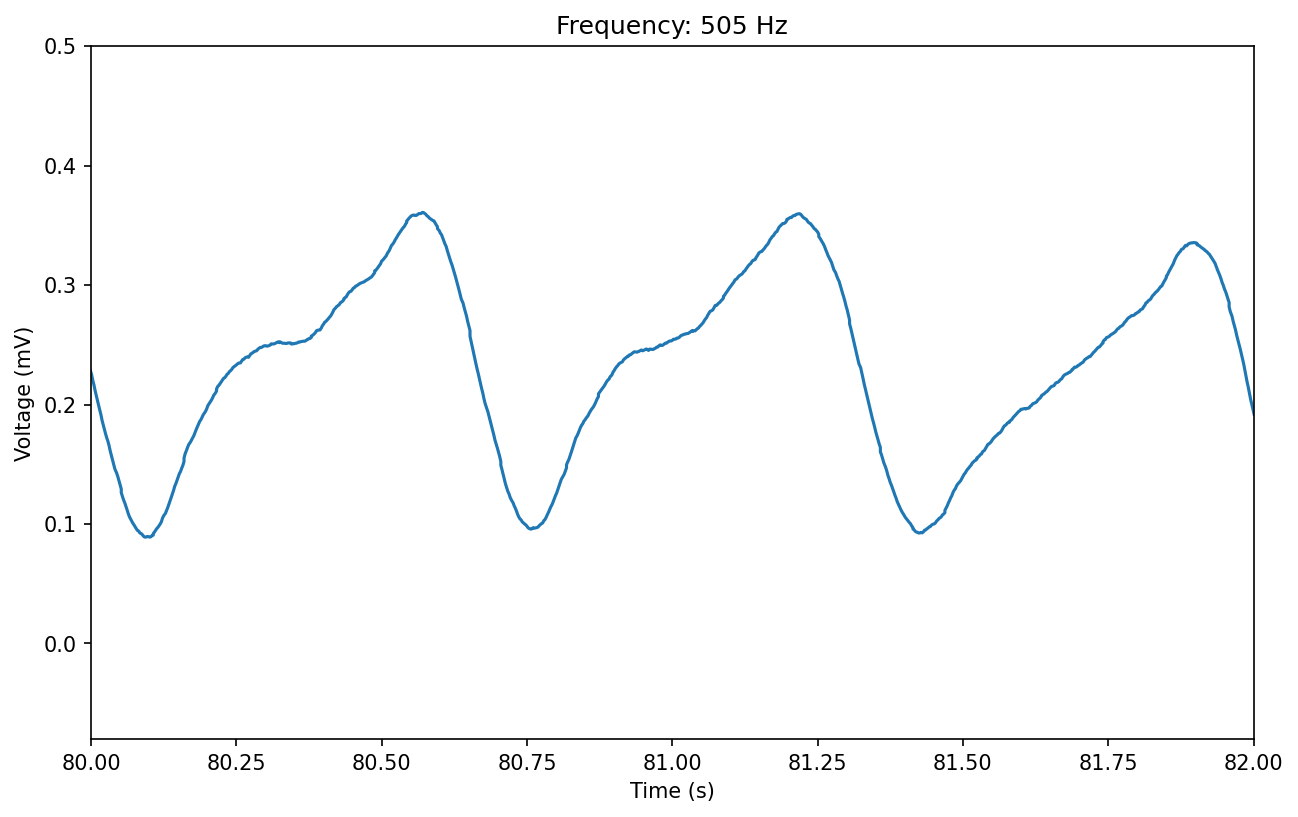

In [95]:
import scipy

v = -1 * data_frame["Voltages"] * 1000
t = data_frame["Times"] / 1000

print(len(t) / 120)

plt.xlabel("Time (s)")
plt.ylabel("Voltage (mV)")

#plt.plot(t, v)
smoothed = scipy.signal.savgol_filter(v, window_length = 200, polyorder = 5)
plt.plot(t, smoothed)

plt.xlim(80, 82)
plt.ylim(-0.08, 0.5)


plt.title(f"Frequency: {int(np.round(len(t) / 120, 0))} Hz")